# Weighted Fields: Velocity and Momentum Density

`Convols` is not limited to the catalogue-normalized tracer field used in the basic examples. It separates relative catalogue weights $w_{g,i}$ from physical field values $x_i$. With the default `weight_normalization="catalog"`, the projected marked field is

$$
F_x(\mathbf{x}) = \sum_i \frac{w_{g,i}}{\sum_j w_{g,j}} x_i \, \delta_\mathrm{D}^{(3)}(\mathbf{x} - \mathbf{x}_i),
$$

changing `field_value` changes the physical field represented by the same wavelet machinery without changing the catalogue measure. For true extensive fields such as momentum density, this notebook switches to `weight_normalization="raw"`, so the field keeps the raw weighted amplitude instead of dividing by the catalogue weight sum.

This notebook uses the Quijote halo catalog to construct and compare three related fields:

- a catalogue-normalized halo tracer field $n_h(\mathbf{x})$ from unit field values;
- velocity-weighted fields $n_{v_x}(\mathbf{x})$, $n_{v_y}(\mathbf{x})$, and $n_{v_z}(\mathbf{x})$, combined into

$$
\mathbf{v}(\mathbf{x}) = \frac{\mathbf{n}_v(\mathbf{x})}{n_h(\mathbf{x})};
$$

- halo momentum-density fields

$$
\mathbf{p}(\mathbf{x}) = \mathbf{n}_{m\mathbf{v}}(\mathbf{x}),
$$

whose divergence is plotted as $(\nabla \cdot \mathbf{p}) / \bar{\rho}_h$.

The main derivative method in this notebook is the PyHermes derivative-window method. Finite differences are kept as a reference calculation on an independent regular grid.

## Workflow

1. Build the globally Gaussian-smoothed $n_h$ and $\mathbf{n}_v$ fields.
2. Visualize the velocity field on a random-point two-dimensional slice.
3. Use derivative windows on the same random points to compute $\nabla\cdot\mathbf{v}$ and $\nabla\times\mathbf{v}$.
4. Build $\mathbf{p}$ and use derivative windows to compute $\nabla\cdot\mathbf{p}$ and $\nabla\times\mathbf{p}$.
5. Compute finite-difference velocity and momentum-density divergences on a regular grid.
6. Sample a subset of that regular grid and compare finite differences with derivative-window derivatives at the same positions.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pyhermes.base.convols import Convols
from pyhermes.io import read_particle_data
from pyhermes.io.convols import ConvolsData
from pyhermes.io.window import WindowFunc
from pyhermes.utils.sampling import random_box_positions, regular_grid_positions

from pathlib import Path
import os
os.chdir(Path.cwd().resolve().parent)
print(f"Working directory: {Path.cwd()}")

figs_dir = Path("figs")
figs_dir.mkdir(exist_ok=True)

Working directory: /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples


In [2]:
catalog_path = "./data/quijote_halos/8000"
box_size = 1000.0
reader_params = {
    "snapnum": 4,
    "redshift": 0.0,
    "fields": {
        "vx": "vel_x",
        "vy": "vel_y",
        "vz": "vel_z",
        "mass": "mass",
    }
}
halo_data = read_particle_data(catalog_path, data_format="fof", **reader_params)


17:06:40 - INFO - pyhermes.io.readers:read_particle_data - Selected input particle format: fof
17:06:40 - INFO - pyhermes.io.readers:read_fof - Reading Quijote FoF halo data from ---> ./data/quijote_halos/8000 <---


In [3]:
base_params = {
    "box_size": box_size,
    "J": 8,
    "wavelet_mode": "db2",
    "wavelet_level": 10,
    "phi_resolution": 1024,
}
threads = 8

density_floor_fraction = 0.0
smoothing_scale = 10.0  # Mpc/h
win_gauss = WindowFunc(
    {"type": "gaussian", "len_args": {"R": smoothing_scale}},
    base_params,
    threads=threads,
)

print(f"Global Gaussian smoothing scale: R = {smoothing_scale} Mpc/h")
print(f"Density floor fraction: {density_floor_fraction:g}")


Global Gaussian smoothing scale: R = 10.0 Mpc/h
Density floor fraction: 0


In [4]:
def build_field(pos, field_value=None, weight_normalization="catalog"):
    task_params = {**base_params, "weight_normalization": weight_normalization}
    task = Convols({"Convols": task_params})
    task.particle_pos = np.array(pos, copy=True)
    if field_value is not None:
        task.field_value = np.array(field_value, copy=True)
    task.threads = threads
    return task.run(save_result=False)

count_data = build_field(halo_data["pos"]) @ win_gauss
v_data = [build_field(halo_data["pos"], field_value=halo_data[key]) @ win_gauss for key in ["vx", "vy", "vz"]]

17:06:40 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
17:06:40 - INFO - pyhermes.pipeline.pipeline:Convols - Convols runtime configuration: running on 1 MPI ranks with 8 threads per rank
17:06:40 - INFO - pyhermes.pipeline.pipeline:Convols - Preparing Convols input fields ...
17:06:40 - INFO - pyhermes.pipeline.pipeline:Convols - J=8, L=256, box_size=1000.0, phi_resolution=1024, wavelet_mode=db2, wavelet_level=10
17:06:40 - INFO - pyhermes.pipeline.pipeline:Convols - No catalog_weight provided; using unit catalogue weights for 406728 particles.
17:06:40 - INFO - pyhermes.pipeline.pipeline:Convols - Input particles ready | source=custom particle_pos array | particle_count=406728 | catalog_weight_key=None | field_value_key=None | weight_normalization=catalog | catalog_weight_sum=4.067280e+05 | field_integral=1.000000e+00
17:06:40 - INFO - pyhermes.pipeline.pipeline:Convols - Single process mode
17:06:41 - INFO - pyhermes.pipeline.pipeline:Conv

## 1. Random-Point Velocity Slice

The velocity-weighted fields by themselves have units of number density times velocity, so the velocity field is reconstructed as

$$
\mathbf{v}(\mathbf{x}) = \frac{\mathbf{n}_v(\mathbf{x})}{n_h(\mathbf{x})}.
$$

The random points are used first for a two-dimensional slice and then reused for the derivative-window velocity derivatives.


In [5]:
num_random_points = 300_000
random_pos = random_box_positions(count=num_random_points, box_size=box_size, seed=42).astype(np.float32)

n_random = count_data.field_density_at_pos(random_pos, value_unit="physical").astype(np.float64)
random_density_floor = density_floor_fraction * np.max(np.abs(n_random))
random_density_mask = np.abs(n_random) > random_density_floor
velocity_random_pos = random_pos[random_density_mask]
n_velocity_random = n_random[random_density_mask]

v_at_random = np.column_stack([
    component_data.field_density_at_pos(velocity_random_pos, value_unit="physical").astype(np.float64) / n_velocity_random
    for component_data in v_data
])

print("Random velocity points above density floor:", velocity_random_pos.shape[0], "/", random_pos.shape[0])


Random velocity points above density floor: 300000 / 300000


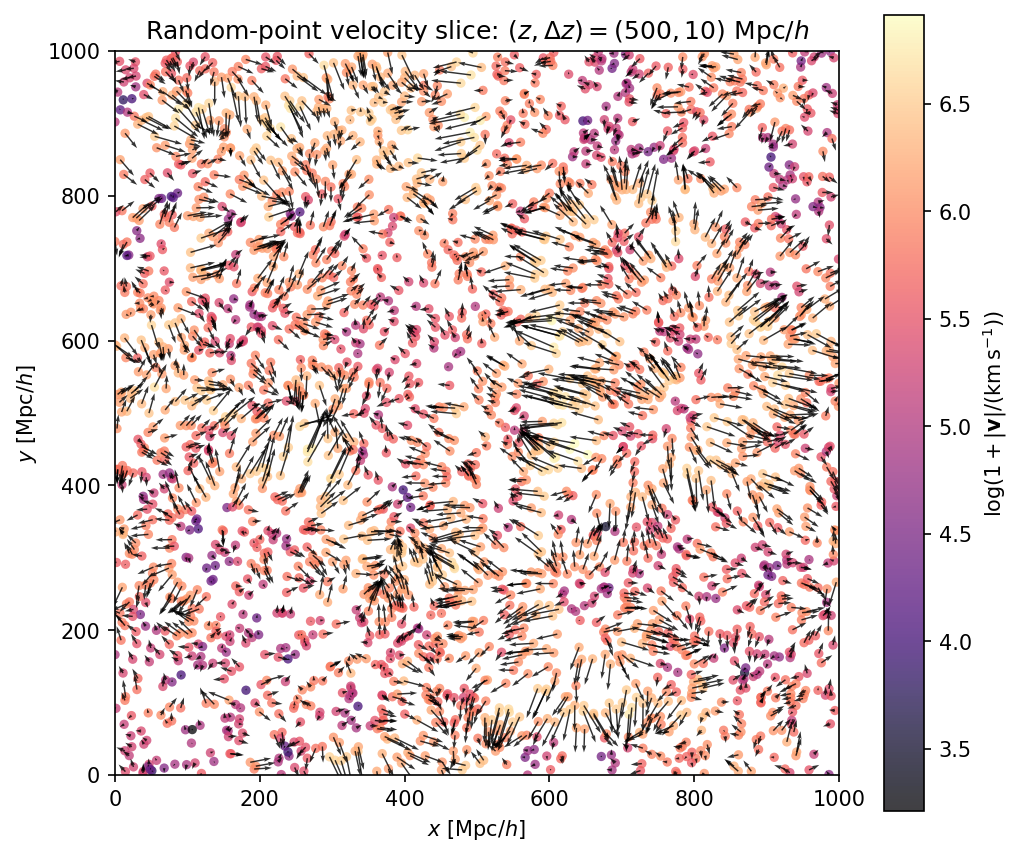

In [6]:
z0 = 500.0
slice_thickness = 10.0

dz_slice = (velocity_random_pos[:, 2] - z0 + 0.5 * box_size) % box_size - 0.5 * box_size
slice_mask = np.abs(dz_slice) < 0.5 * slice_thickness

pos2d = velocity_random_pos[slice_mask]
vel2d = v_at_random[slice_mask]
vx, vy, vz = vel2d.T
speed = np.sqrt(vx**2 + vy**2 + vz**2)

fig, ax = plt.subplots(figsize=(7, 6), dpi=150)

sc = ax.scatter(pos2d[:, 0], pos2d[:, 1], c=np.log1p(speed),
                cmap="magma", s=20, alpha=0.75, linewidths=0)
ax.quiver(pos2d[:, 0], pos2d[:, 1], vx, vy, color="k", angles="xy", 
          scale_units="xy", scale=15, width=0.002, alpha=0.8)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r"$\log(1 + |\mathbf{v}| / ({\rm km\,s}^{-1}))$")

ax.set_xlim(0, box_size)
ax.set_ylim(0, box_size)
ax.set_aspect("equal")
ax.set_xlabel(r"$x\ [{\rm Mpc}/h]$")
ax.set_ylabel(r"$y\ [{\rm Mpc}/h]$")
ax.set_title(fr"Random-point velocity slice: $(z, \Delta z)=({z0:.0f}, {slice_thickness:.0f})\ {{\rm Mpc}}/h$", fontsize=12)

plt.tight_layout()
fig.savefig(figs_dir / "weighted_fields_velocity_slice.png", dpi=200, bbox_inches="tight")
plt.show()

## 2. Velocity Derivatives From Derivative Windows

For a periodic field,

$$
\widetilde{\partial_{\hat n} f}(\mathbf{k}) =
2\pi i (\mathbf{k}\cdot\hat{\mathbf{n}})\tilde f(\mathbf{k}),
$$

so a directional derivative is a Fourier-space window. The smoothed velocity field is a ratio,

$$
v_i(\mathbf{x}) = \frac{n_{v_i}(\mathbf{x})}{n_h(\mathbf{x})},
$$

therefore its derivative is evaluated with the quotient rule,

$$
\partial_j v_i =
\frac{\partial_j n_{v_i}}{n_h}
-
\frac{n_{v_i}\,\partial_j n_h}{n_h^2}.
$$

Because the derivative is taken by the PyHermes window, the evaluation positions do not need to lie on a regular grid.


In [7]:
deriv_physical_factor = count_data.scale_factor


def make_derivative_window(nx, ny, nz):
    return WindowFunc(
        {
            "type": "directional_derivative",
            "los_args": {"nx": nx, "ny": ny, "nz": nz},
        },
        count_data.convols_info,
        threads=threads,
    )


derivative_windows = [
    make_derivative_window(1.0, 0.0, 0.0),
    make_derivative_window(0.0, 1.0, 0.0),
    make_derivative_window(0.0, 0.0, 1.0),
]


def sample_fields_at_pos(field_data_list, pos):
    return np.vstack([field_data.field_density_at_pos(pos, value_unit="physical").astype(np.float64) for field_data in field_data_list])


def sample_directional_derivatives(field_data_list, pos):
    gradient = np.empty((len(field_data_list), 3, pos.shape[0]), dtype=np.float64)
    for component_index, field_data in enumerate(field_data_list):
        for direction_index, window in enumerate(derivative_windows):
            gradient[component_index, direction_index] = (
                (field_data @ window).field_density_at_pos(pos, value_unit="physical").astype(np.float64) * deriv_physical_factor
            )
    return gradient


def divergence_and_curl_from_gradient(gradient):
    divergence = gradient[0, 0] + gradient[1, 1] + gradient[2, 2]
    curl = np.column_stack([
        gradient[2, 1] - gradient[1, 2],
        gradient[0, 2] - gradient[2, 0],
        gradient[1, 0] - gradient[0, 1],
    ])
    return divergence, curl


def vector_derivatives_at_pos(component_data_list, pos):
    return divergence_and_curl_from_gradient(sample_directional_derivatives(component_data_list, pos))


def velocity_derivatives_at_pos(pos):
    n_values = count_data.field_density_at_pos(pos, value_unit="physical").astype(np.float64)
    density_floor = density_floor_fraction * np.max(np.abs(n_values))
    density_mask = np.abs(n_values) > density_floor

    inv_n = np.zeros_like(n_values)
    np.divide(1.0, n_values, out=inv_n, where=density_mask)

    nv_values = sample_fields_at_pos(v_data, pos)
    dn_values = sample_directional_derivatives([count_data], pos)[0]
    dnv_values = sample_directional_derivatives(v_data, pos)
    velocity_gradient = (
        dnv_values * inv_n[None, None, :]
        - nv_values[:, None, :] * dn_values[None, :, :] * inv_n[None, None, :]**2
    )

    divergence, curl = divergence_and_curl_from_gradient(velocity_gradient)
    return divergence, curl, density_mask


Derivative-window velocity points above density floor: 300000 / 300000


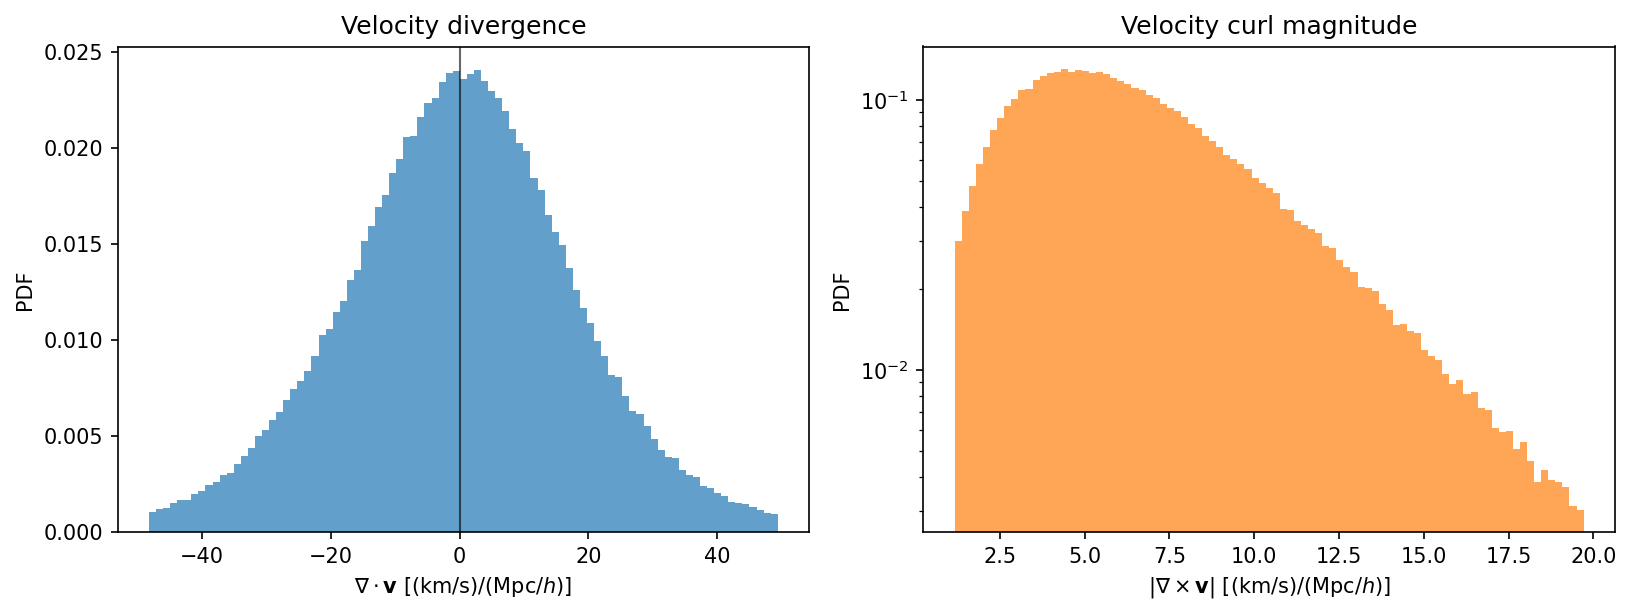

In [8]:
v_div_window_random, v_curl_window_random, velocity_window_mask = velocity_derivatives_at_pos(random_pos)
v_div_window_pdf = v_div_window_random[velocity_window_mask]
v_curl_window_pdf = np.linalg.norm(v_curl_window_random[velocity_window_mask], axis=1)

print("Derivative-window velocity points above density floor:", velocity_window_mask.sum(), "/", random_pos.shape[0])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), dpi=150)

for ax, pdf, color, title, xlabel in zip(
    axes,
    [v_div_window_pdf, v_curl_window_pdf],
    ["tab:blue", "tab:orange"],
    ["Velocity divergence", "Velocity curl magnitude"],
    [
        r"$\nabla \cdot \mathbf{v}\ [({\rm km}/{\rm s})/({\rm Mpc}/h)]$",
        r"$|\nabla \times \mathbf{v}|\ [({\rm km}/{\rm s})/({\rm Mpc}/h)]$",
    ],
):
    lo, hi = np.percentile(pdf, (1, 99))
    ax.hist(pdf, bins=np.linspace(lo, hi, 90), density=True, 
            histtype="stepfilled", color=color, alpha=0.7)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("PDF")
    ax.set_title(title)
    if "curl" in title.lower():
        ax.set_yscale("log")
    else:
        ax.axvline(0.0, color="k", lw=1, alpha=0.6)

plt.tight_layout()
fig.savefig(figs_dir / "weighted_fields_velocity_derivatives_pdf.png", dpi=200, bbox_inches="tight")
plt.show()


The velocity divergence can also be visualized on the same two-dimensional slice. The left panel below shows the derivative-window velocity divergence with the same random-point velocity arrows as before. The right panel shows the linear-theory prediction from the downloaded dark-matter density field, $-(aHf/h)\,\delta_m$, on the same slice. The next cell summarizes the same comparison with a hexbin plot.

17:06:49 - INFO - pyhermes.io.base:ConvolsData - Reading Convols data from ---> output/quijote_fiducial_8000_snap004_dm_sfc_J8.pkl <---
17:06:49 - INFO - pyhermes.io.base:ConvolsData - epsilon: Shape(256, 256, 256), Min = -4.192e-06, Max = 3.069e-05, Mean = 5.96e-08, Sum = 1


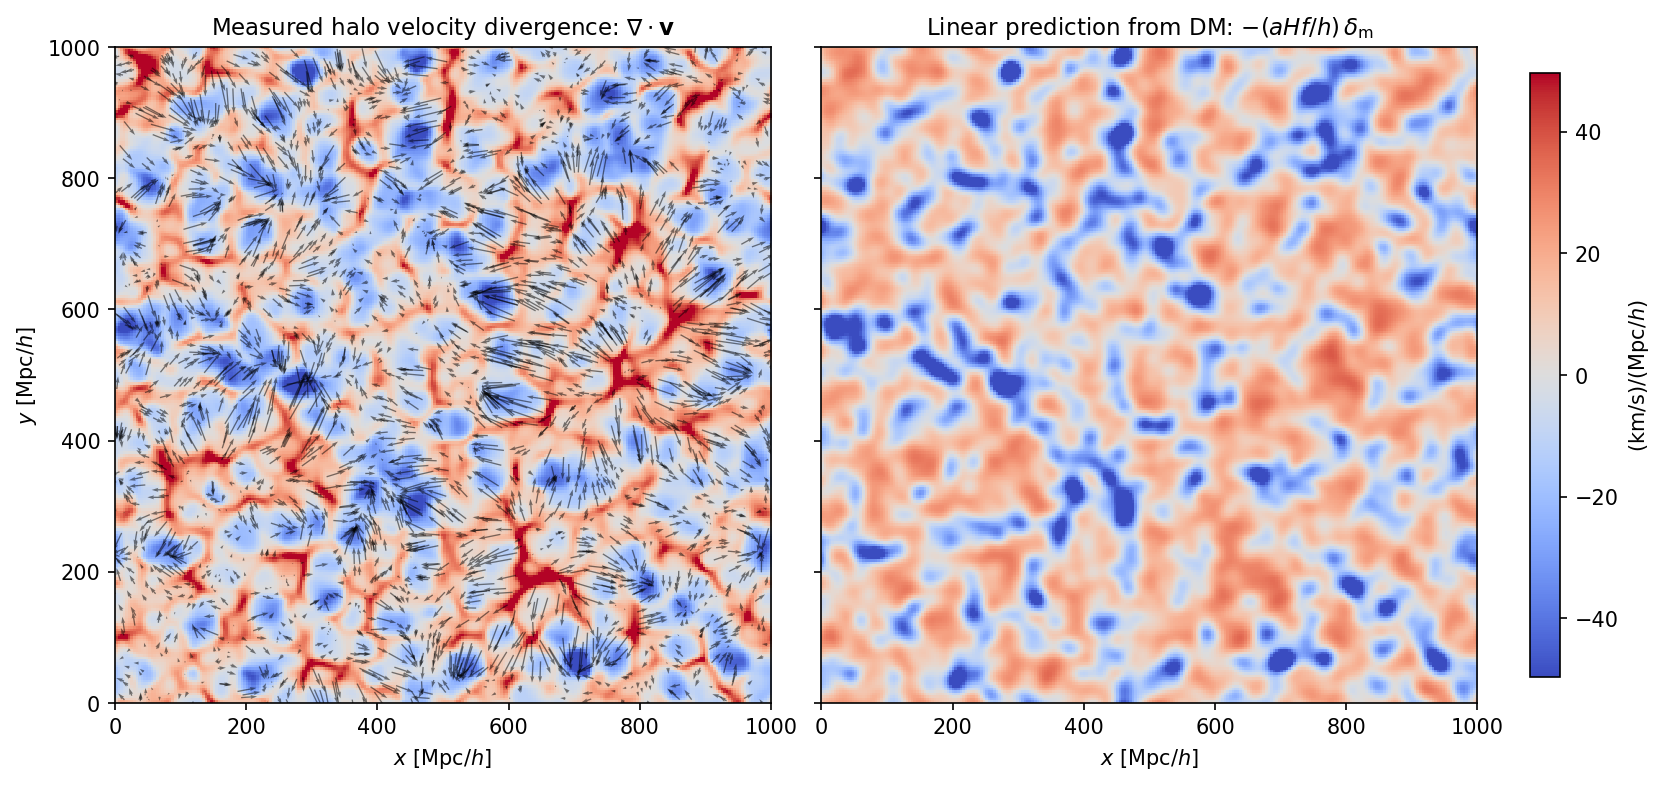

In [9]:
slice_grid_resolution = 256
slice_axis = ((np.arange(slice_grid_resolution, dtype=np.float32) + 0.5) * box_size / slice_grid_resolution) % box_size
slice_x, slice_y = np.meshgrid(slice_axis, slice_axis, indexing="ij")
slice_eval_pos = np.column_stack([
    slice_x.ravel(),
    slice_y.ravel(),
    np.full(slice_x.size, z0, dtype=np.float32),
]).astype(np.float32)

v_div_slice, _, slice_density_mask = velocity_derivatives_at_pos(slice_eval_pos)

dm_convols_path = Path("output") / "quijote_fiducial_8000_snap004_dm_sfc_J8.pkl"
dm_count_data = ConvolsData(data_path=str(dm_convols_path), threads=threads)
dm_density_smoothed = dm_count_data @ win_gauss
dm_delta_data = dm_density_smoothed / dm_density_smoothed.field_mean_density(value_unit="grid") - 1.0
dm_delta_slice = dm_delta_data.field_density_at_pos(slice_eval_pos, value_unit="grid").astype(np.float64)

omega_m0 = 0.3175
redshift = 0.0
a = 1.0 / (1.0 + redshift)
E_z = np.sqrt(omega_m0 * (1.0 + redshift)**3 + (1.0 - omega_m0))
omega_m_z = omega_m0 * (1.0 + redshift)**3 / E_z**2
f_growth = omega_m_z**0.55
vdiv_to_delta = a * 100.0 * E_z * f_growth  # (km/s)/(Mpc/h)
dm_vdiv_prediction_slice = -dm_delta_slice * vdiv_to_delta

valid_vdiv_dm = slice_density_mask & np.isfinite(v_div_slice) & np.isfinite(dm_vdiv_prediction_slice)
corr_vdiv_dm = np.corrcoef(dm_vdiv_prediction_slice[valid_vdiv_dm], v_div_slice[valid_vdiv_dm])[0, 1]

v_div_grid = np.where(slice_density_mask, v_div_slice, np.nan).reshape(slice_x.shape)
dm_vdiv_prediction_grid = dm_vdiv_prediction_slice.reshape(slice_x.shape)
plot_limit = np.nanpercentile(np.abs(np.concatenate([
    v_div_slice[valid_vdiv_dm],
    dm_vdiv_prediction_slice[valid_vdiv_dm],
])), 98)
if not np.isfinite(plot_limit) or plot_limit == 0.0:
    plot_limit = 1.0

fig, axes = plt.subplots(1, 2, figsize=(11, 5.2), dpi=150, constrained_layout=True, sharey=True)

for ax, grid, title in zip(
    axes,
    [v_div_grid, dm_vdiv_prediction_grid],
    [
        r"Measured halo velocity divergence: $\nabla\cdot\mathbf{v}$",
        r"Linear prediction from DM: $-(aHf/h)\,\delta_{\rm m}$",
    ],
):
    im = ax.imshow(
        grid.T,
        origin="lower",
        extent=(0.0, box_size, 0.0, box_size),
        cmap="coolwarm",
        vmin=-plot_limit,
        vmax=plot_limit,
        interpolation="nearest",
    )
    ax.set_xlim(0, box_size)
    ax.set_ylim(0, box_size)
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x\ [{\rm Mpc}/h]$")
    ax.set_title(title, fontsize=11)

axes[0].set_ylabel(r"$y\ [{\rm Mpc}/h]$")
cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
cbar.set_label(r"$({\rm km}/{\rm s})/({\rm Mpc}/h)$")

axes[0].quiver(pos2d[:, 0], pos2d[:, 1], vx, vy, color="k", angles="xy",
               scale_units="xy", scale=15, width=0.002, alpha=0.5)
# fig.suptitle(
#     fr"Velocity divergence vs. DM linear prediction: $z_{{\rm box}}={z0:.0f}\ {{\rm Mpc}}/h$, "
#     fr"Gaussian $R={smoothing_scale:g}\ {{\rm Mpc}}/h$",
#     y=1.03,
# )

fig.savefig(figs_dir / "weighted_fields_velocity_divergence_dm_prediction_slice.png", dpi=200, bbox_inches="tight")
plt.show()


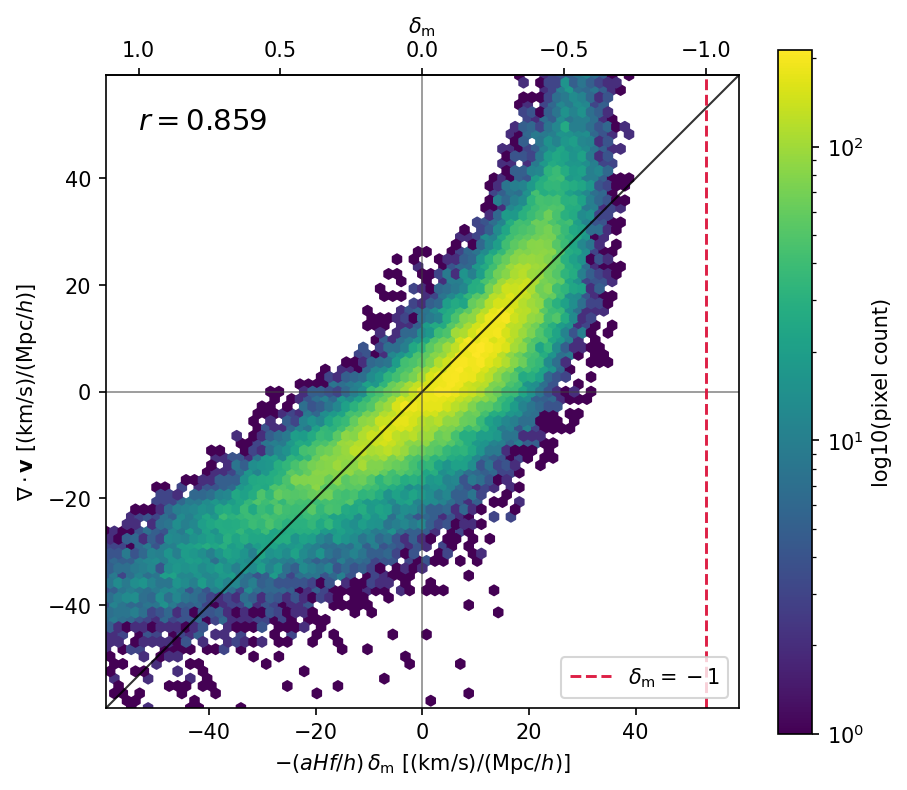

In [10]:
prediction_plot = dm_vdiv_prediction_slice[valid_vdiv_dm]
vdiv_plot = v_div_slice[valid_vdiv_dm]
scatter_limit = np.nanpercentile(np.abs(np.concatenate([prediction_plot, vdiv_plot])), 99)
if not np.isfinite(scatter_limit) or scatter_limit == 0.0:
    scatter_limit = 1.0
delta_minus_one_x = vdiv_to_delta
scatter_limit = max(scatter_limit, 1.05 * abs(delta_minus_one_x))

fig, ax = plt.subplots(figsize=(6.2, 5.4), dpi=150)
hb = ax.hexbin(
    prediction_plot,
    vdiv_plot,
    gridsize=75,
    bins="log",
    mincnt=1,
    cmap="viridis",
    extent=(-scatter_limit, scatter_limit, -scatter_limit, scatter_limit),
)
ax.plot([-scatter_limit, scatter_limit], [-scatter_limit, scatter_limit], color="k", lw=1, alpha=0.8)
ax.axhline(0.0, color="0.25", lw=0.8, alpha=0.6)
ax.axvline(0.0, color="0.25", lw=0.8, alpha=0.6)
ax.axvline(delta_minus_one_x, color="crimson", ls="--", lw=1.4, alpha=0.95, label=r"$\delta_{\rm m}=-1$")
ax.set_xlim(-scatter_limit, scatter_limit)
ax.set_ylim(-scatter_limit, scatter_limit)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$-(aHf/h)\,\delta_{\rm m}\ [({\rm km}/{\rm s})/({\rm Mpc}/h)]$")
ax.set_ylabel(r"$\nabla\cdot\mathbf{v}\ [({\rm km}/{\rm s})/({\rm Mpc}/h)]$")
ax.text(0.05, 0.95, fr"$r={corr_vdiv_dm:.3f}$", transform=ax.transAxes, ha="left", va="top", fontsize=14)

top_ax = ax.secondary_xaxis(
    "top",
    functions=(lambda x: -x / vdiv_to_delta, lambda delta: -delta * vdiv_to_delta),
)
top_ax.set_xlabel(r"$\delta_{\rm m}$")
top_ax.set_xticks([-1.0, -0.5, 0.0, 0.5, 1.0])
ax.legend(loc="lower right", frameon=True)

cbar = fig.colorbar(hb, ax=ax)
cbar.set_label("log10(pixel count)")

plt.tight_layout()
fig.savefig(figs_dir / "weighted_fields_velocity_divergence_dm_prediction_hexbin.png", dpi=200, bbox_inches="tight")
plt.show()


## 3. Momentum-Density Derivatives From Derivative Windows

This section adds mass information. The momentum-density components are built with $m_a v_{a,i}$ weights,

$$
p_i(\mathbf{x}) = \sum_a m_a v_{a,i} W(\mathbf{x} - \mathbf{x}_a).
$$

Unlike the velocity field, this is a linear weighted field, so no quotient rule is needed. For plotting, derivatives of $\mathbf{p}$ are divided by the mean halo mass density $\bar{\rho}_h$, giving the same velocity-per-length units as the velocity derivatives.


17:06:51 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
17:06:51 - INFO - pyhermes.param.parambase:ParamBase - Default 'Convols.weight_normalization' from 'catalog' to 'raw'
17:06:51 - INFO - pyhermes.pipeline.pipeline:Convols - Convols runtime configuration: running on 1 MPI ranks with 8 threads per rank
17:06:51 - INFO - pyhermes.pipeline.pipeline:Convols - Preparing Convols input fields ...
17:06:51 - INFO - pyhermes.pipeline.pipeline:Convols - J=8, L=256, box_size=1000.0, phi_resolution=1024, wavelet_mode=db2, wavelet_level=10
17:06:51 - INFO - pyhermes.pipeline.pipeline:Convols - No catalog_weight provided; using unit catalogue weights for 406728 particles.
17:06:51 - INFO - pyhermes.pipeline.pipeline:Convols - Input particles ready | source=custom particle_pos array | particle_count=406728 | catalog_weight_key=None | field_value_key=custom | weight_normalization=raw | catalog_weight_sum=4.067280e+05 | field_integral=1.964693e+19
17:06:51

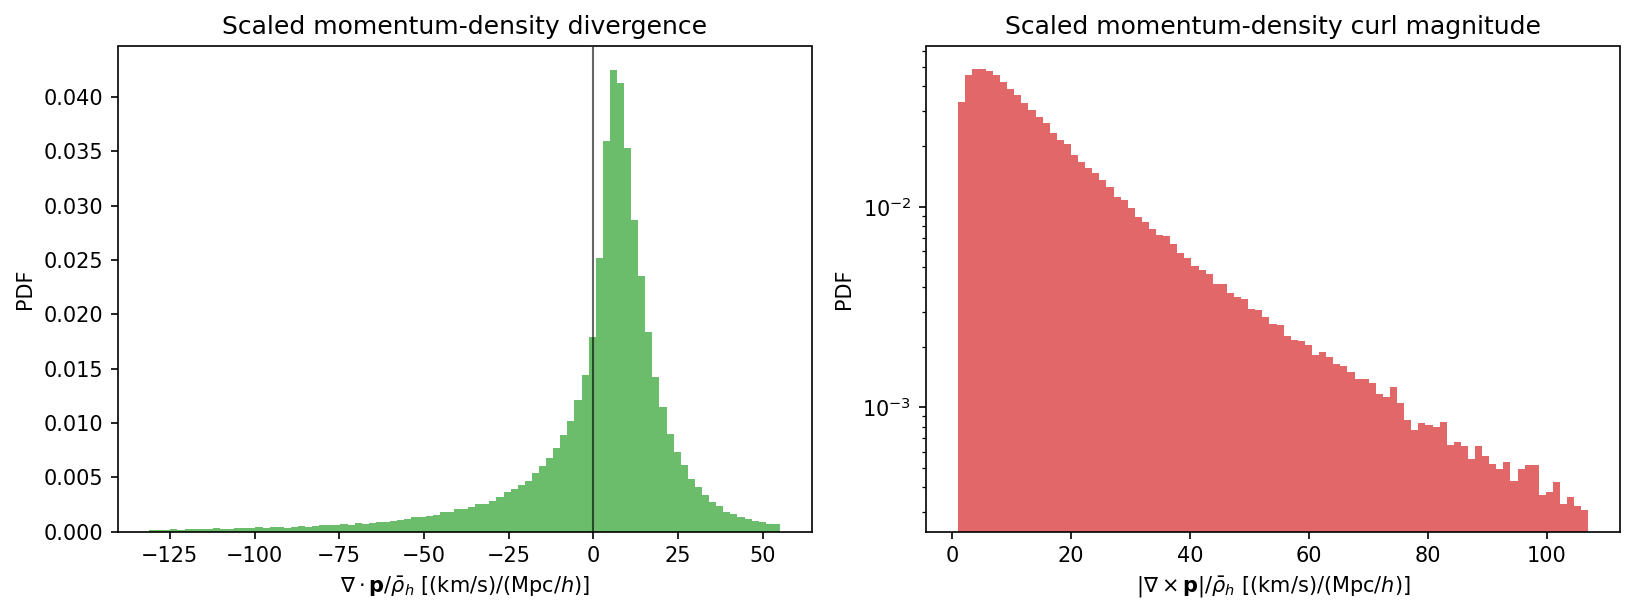

In [11]:
mass_data = build_field(halo_data["pos"], field_value=halo_data["mass"], weight_normalization="raw")
rho_mean = mass_data.field_mean_density(value_unit="physical")
print("mean halo mass density:", rho_mean, "(Msun/h)/(Mpc/h)^3")

p_data = [
    build_field(
        halo_data["pos"],
        field_value=halo_data[velocity_key] * halo_data["mass"],
        weight_normalization="raw",
    ) @ win_gauss
    for velocity_key in ["vx", "vy", "vz"]
]
p_div_window_random, p_curl_window_random = vector_derivatives_at_pos(p_data, random_pos)
p_div_window_pdf = p_div_window_random / rho_mean
p_curl_window_pdf = np.linalg.norm(p_curl_window_random, axis=1) / rho_mean

print("Derivative-window momentum points:", random_pos.shape[0])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), dpi=150)

for ax, pdf, color, title, xlabel in zip(
    axes,
    [p_div_window_pdf, p_curl_window_pdf],
    ["tab:green", "tab:red"],
    ["Scaled momentum-density divergence", "Scaled momentum-density curl magnitude"],
    [
        r"$\nabla \cdot \mathbf{p}/\bar{\rho}_h\ [({\rm km}/{\rm s})/({\rm Mpc}/h)]$",
        r"$|\nabla \times \mathbf{p}|/\bar{\rho}_h\ [({\rm km}/{\rm s})/({\rm Mpc}/h)]$",
    ],
):
    lo, hi = np.percentile(pdf, (1, 99))
    ax.hist(pdf, bins=np.linspace(lo, hi, 90), density=True, 
            histtype="stepfilled", color=color, alpha=0.7)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("PDF")
    ax.set_title(title)
    if "curl" in title.lower():
        ax.set_yscale("log")
    else:
        ax.axvline(0.0, color="k", lw=1, alpha=0.6)

plt.tight_layout()
fig.savefig(figs_dir / "weighted_fields_momentum_derivatives_pdf.png", dpi=200, bbox_inches="tight")
plt.show()


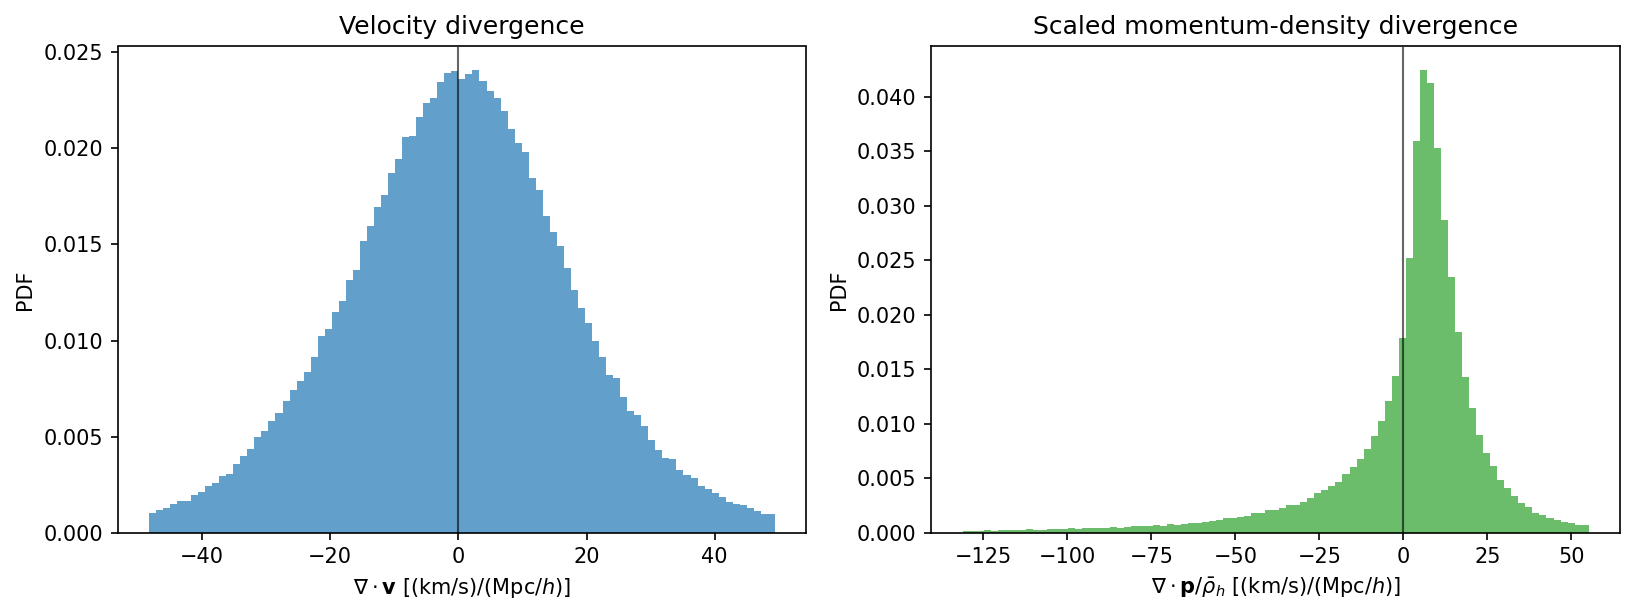

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), dpi=150)

for ax, pdf, color, title, xlabel in zip(
    axes,
    [v_div_window_pdf, p_div_window_pdf],
    ["tab:blue", "tab:green"],
    ["Velocity divergence", "Scaled momentum-density divergence"],
    [
        r"$\nabla \cdot \mathbf{v}\ [({\rm km}/{\rm s})/({\rm Mpc}/h)]$",
        r"$\nabla \cdot \mathbf{p}/\bar{\rho}_h\ [({\rm km}/{\rm s})/({\rm Mpc}/h)]$",
    ],
):
    lo, hi = np.percentile(pdf, (1, 99))
    ax.hist(pdf, bins=np.linspace(lo, hi, 90), density=True,
            histtype="stepfilled", color=color, alpha=0.7)
    ax.axvline(0.0, color="k", lw=1, alpha=0.6)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("PDF")
    ax.set_title(title)

plt.tight_layout()
fig.savefig(figs_dir / "weighted_fields_velocity_momentum_divergence_pdf.png", dpi=200, bbox_inches="tight")
plt.show()


## 4. Finite-Difference Reference On A Regular Grid

Finite differences are useful as an intuitive reference, but they require choosing an evaluation grid. The central-difference derivative converges to the derivative-window result as the grid is refined, and its accuracy depends on the spacing $\Delta x$.

The default grid below is kept moderate for runtime. Increasing `n_eval_grid` gives a tighter finite-difference reference at higher cost.


In [13]:
def sample_vector_field_grid(component_data_list, pos, n_grid):
    return [
        component_data.field_density_at_pos(pos, value_unit="physical").reshape((n_grid, n_grid, n_grid)).astype(np.float32)
        for component_data in component_data_list
    ]


def sample_velocity_grid(pos, n_grid):
    n_values = count_data.field_density_at_pos(pos, value_unit="physical").astype(np.float64)
    density_floor = density_floor_fraction * np.max(np.abs(n_values))
    density_mask = np.abs(n_values) > density_floor

    inv_n = np.zeros_like(n_values)
    np.divide(1.0, n_values, out=inv_n, where=density_mask)

    components = [
        (component_data.field_density_at_pos(pos, value_unit="physical").astype(np.float64) * inv_n).reshape((n_grid, n_grid, n_grid)).astype(np.float32)
        for component_data in v_data
    ]
    return components, density_mask.reshape((n_grid, n_grid, n_grid))


def central_stencil_mask(mask):
    return (
        mask
        & np.roll(mask, 1, axis=0) & np.roll(mask, -1, axis=0)
        & np.roll(mask, 1, axis=1) & np.roll(mask, -1, axis=1)
        & np.roll(mask, 1, axis=2) & np.roll(mask, -1, axis=2)
    )


def periodic_central_diff(field, axis, spacing):
    return (np.roll(field, -1, axis=axis) - np.roll(field, 1, axis=axis)) / (2.0 * spacing)


def vector_field_divergence(x_component, y_component, z_component, spacing):
    return (
        periodic_central_diff(x_component, axis=0, spacing=spacing)
        + periodic_central_diff(y_component, axis=1, spacing=spacing)
        + periodic_central_diff(z_component, axis=2, spacing=spacing)
    )


In [14]:
n_eval_grid = 256
grid_pos, dx = regular_grid_positions(n_eval_grid, box_size)

(vx_grid, vy_grid, vz_grid), velocity_grid_mask = sample_velocity_grid(grid_pos, n_eval_grid)
(px_grid, py_grid, pz_grid) = sample_vector_field_grid(p_data, grid_pos, n_eval_grid)

v_div_fd_grid = vector_field_divergence(vx_grid, vy_grid, vz_grid, spacing=dx)
p_div_fd_grid = vector_field_divergence(px_grid, py_grid, pz_grid, spacing=dx)
velocity_fd_mask = central_stencil_mask(velocity_grid_mask)

print("finite-difference grid:", f"{n_eval_grid}^3", "dx =", dx, "Mpc/h")
print("velocity divergence cells above density floor:", velocity_fd_mask.sum(), "/", v_div_fd_grid.size)
print("momentum divergence cells:", p_div_fd_grid.size)


finite-difference grid: 256^3 dx = 3.90625 Mpc/h
velocity divergence cells above density floor: 16777216 / 16777216
momentum divergence cells: 16777216


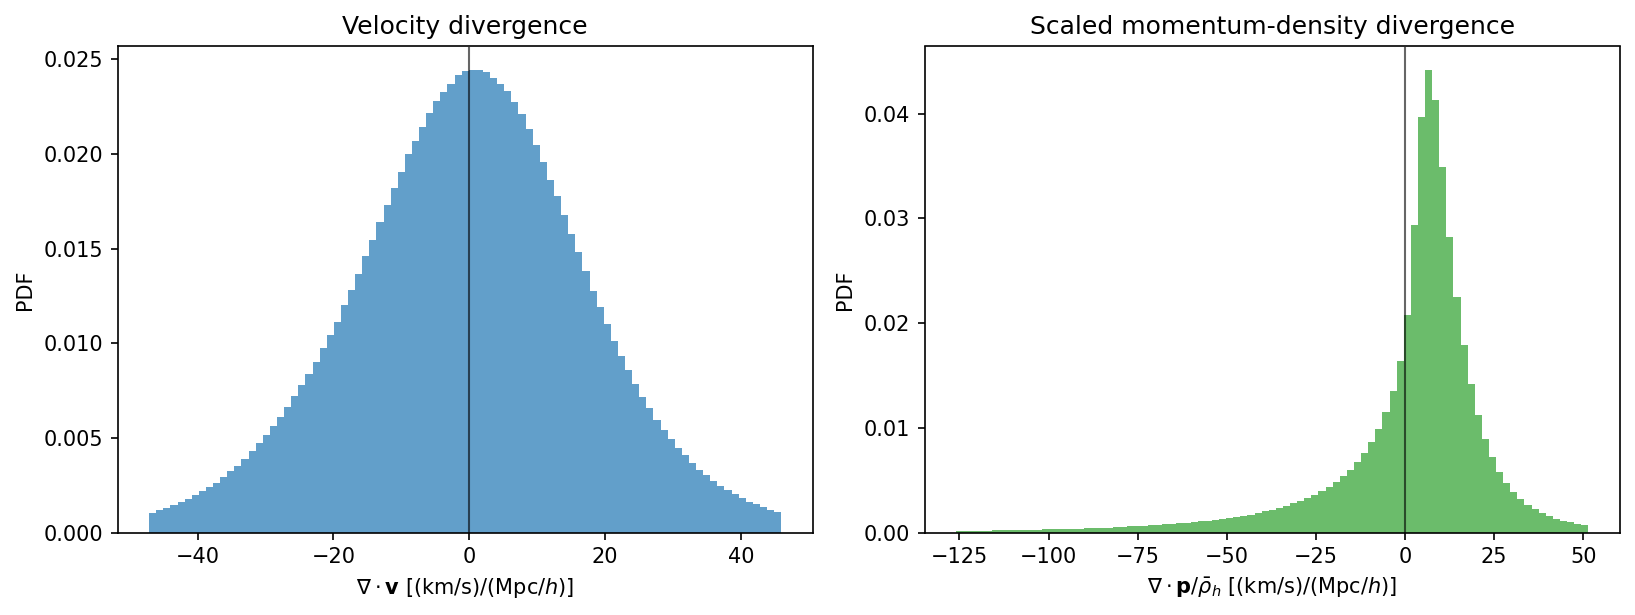

In [15]:
v_div_fd_pdf = v_div_fd_grid[velocity_fd_mask]
p_div_fd_pdf = p_div_fd_grid.ravel() / rho_mean

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), dpi=150)

for ax, pdf, color, title, xlabel in zip(
    axes,
    [v_div_fd_pdf, p_div_fd_pdf],
    ["tab:blue", "tab:green"],
    ["Velocity divergence", "Scaled momentum-density divergence"],
    [
        r"$\nabla \cdot \mathbf{v}\ [({\rm km}/{\rm s})/({\rm Mpc}/h)]$",
        r"$\nabla \cdot \mathbf{p}/\bar{\rho}_h\ [({\rm km}/{\rm s})/({\rm Mpc}/h)]$",
    ],
):
    lo, hi = np.percentile(pdf, (1, 99))
    ax.hist(pdf, bins=np.linspace(lo, hi, 90), density=True,
            histtype="stepfilled", color=color, alpha=0.7)
    ax.axvline(0.0, color="k", lw=1, alpha=0.6)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("PDF")
    ax.set_title(title)

plt.tight_layout()
fig.savefig(figs_dir / "weighted_fields_finite_difference_divergence_pdf.png", dpi=200, bbox_inches="tight")
plt.show()


## 5. Derivative Window Versus Finite Difference

Finally, sample a subset of the regular finite-difference grid and evaluate the derivative-window result at the same positions. The comparison uses finite difference on the horizontal axis and derivative windows on the vertical axis.


In [16]:
max_comparison_points = 50_000
comparison_candidates = np.flatnonzero(velocity_fd_mask.ravel())

rng = np.random.default_rng(123)
if comparison_candidates.size > max_comparison_points:
    comparison_index = rng.choice(comparison_candidates, size=max_comparison_points, replace=False)
else:
    comparison_index = comparison_candidates

comparison_pos = grid_pos[comparison_index]

v_div_fd_sample = v_div_fd_grid.ravel()[comparison_index]
p_div_fd_sample = p_div_fd_grid.ravel()[comparison_index] / rho_mean

v_div_window_sample, _, comparison_density_mask = velocity_derivatives_at_pos(comparison_pos)
p_div_window_sample, _ = vector_derivatives_at_pos(p_data, comparison_pos)
p_div_window_sample = p_div_window_sample / rho_mean

v_div_fd_sample = v_div_fd_sample[comparison_density_mask]
v_div_window_sample = v_div_window_sample[comparison_density_mask]


def compare_stats(old_values, new_values):
    corr = np.corrcoef(old_values, new_values)[0, 1]
    rms = np.sqrt(np.mean((new_values - old_values) ** 2))
    return corr, rms, old_values.size


v_corr, v_rms, v_n = compare_stats(v_div_fd_sample, v_div_window_sample)
p_corr, p_rms, p_n = compare_stats(p_div_fd_sample, p_div_window_sample)

print(f"Comparison points sampled: {comparison_index.size}")
print(f"Velocity divergence comparison cells: {v_n}, corr={v_corr:.4f}, RMS={v_rms:.4g}")
print(f"Momentum divergence comparison cells: {p_n}, corr={p_corr:.4f}, RMS={p_rms:.4g}")


Comparison points sampled: 50000
Velocity divergence comparison cells: 50000, corr=0.9994, RMS=0.7611
Momentum divergence comparison cells: 50000, corr=0.9998, RMS=0.9133


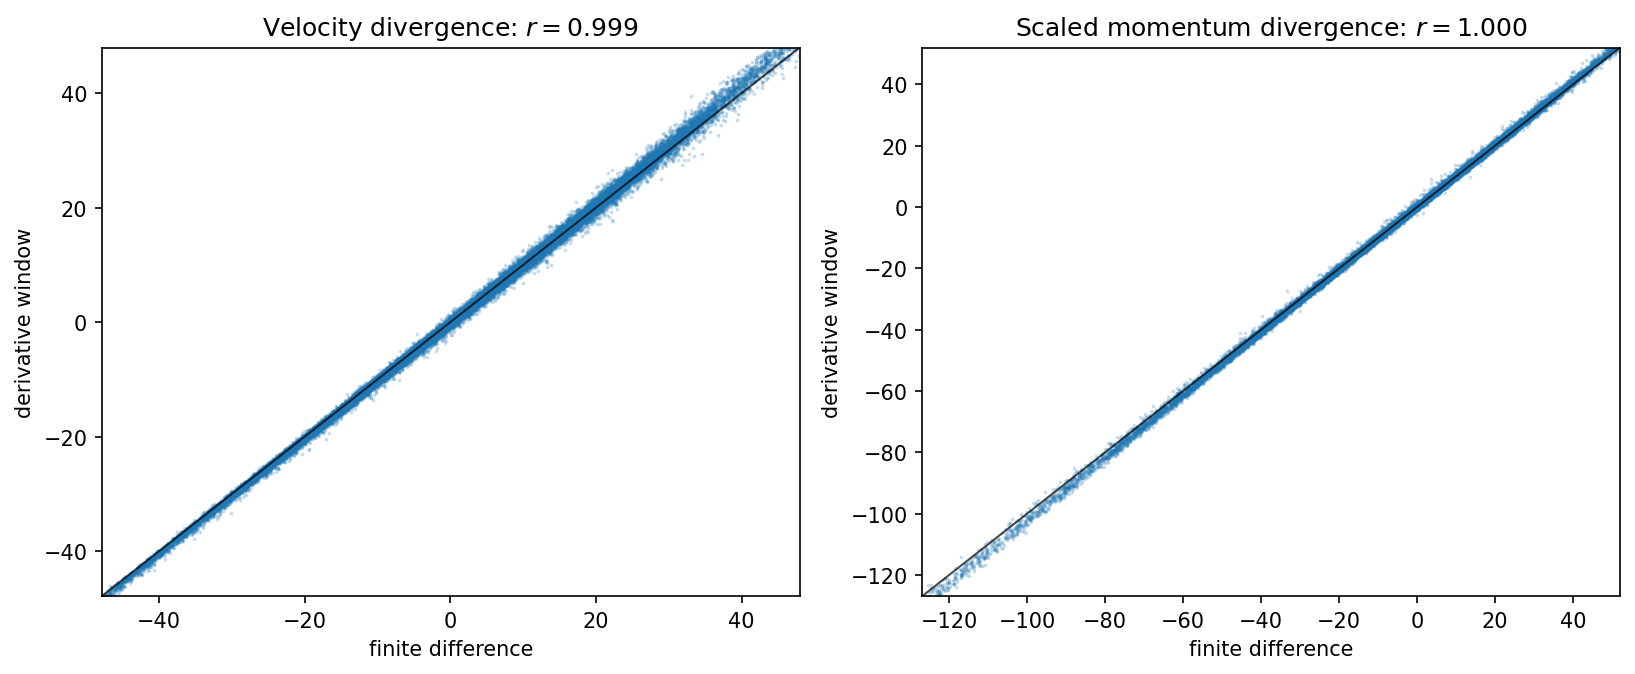

In [17]:
def scatter_compare(ax, old_values, new_values, xlabel, ylabel, title):
    ax.scatter(old_values, new_values, s=3, alpha=0.25, linewidths=0)
    lo, hi = np.percentile(np.concatenate([old_values, new_values]), [1, 99])
    ax.plot([lo, hi], [lo, hi], color="k", lw=1, alpha=0.7)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)


fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), dpi=150)

scatter_compare(
    axes[0],
    v_div_fd_sample,
    v_div_window_sample,
    "finite difference",
    "derivative window",
    fr"Velocity divergence: $r={v_corr:.3f}$",
)
scatter_compare(
    axes[1],
    p_div_fd_sample,
    p_div_window_sample,
    "finite difference",
    "derivative window",
    fr"Scaled momentum divergence: $r={p_corr:.3f}$",
)

plt.tight_layout()
fig.savefig(figs_dir / "weighted_fields_derivative_window_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
